### Notebook running Quantum State Tomography (QST) Algorithms
Algorithms implemented:
1) Maximum Likelihood Estimation (MLE)

In [ ]:
# Import Packages
import numpy as np
import matplotlib.pyplot as plt

import qutip as q
from tqdm.notebook import tqdm

from artificial_samples import cat, sqv, pssqv, spssqv, sample_homodyne
from MLE_class import MLE
from plotting import plot_dm, plot_Wigner, plot_fidelities

In [2]:
# Define target cat state parameters
N_cutoff = 50
parity = 0
theta = np.pi/4
alpha = np.sqrt(5)*np.exp(1j*theta)
# Generate target state
state = cat(N_cutoff, parity, alpha)

In [3]:
# Define target squeezed vacuum state parameters
N_cutoff = 50
r = 1.0
# Generate target state
state = sqv(N_cutoff, r)

In [69]:
# ON state parameters
N_cutoff = 50
n = 3
parity = 0
# Generate target state
ket = np.zeros(N_cutoff, dtype=complex)
ket[0] = 1/np.sqrt(2)
ket[n] = (-1)**parity / np.sqrt(2)
state = q.Qobj(ket)
rho = state.full()


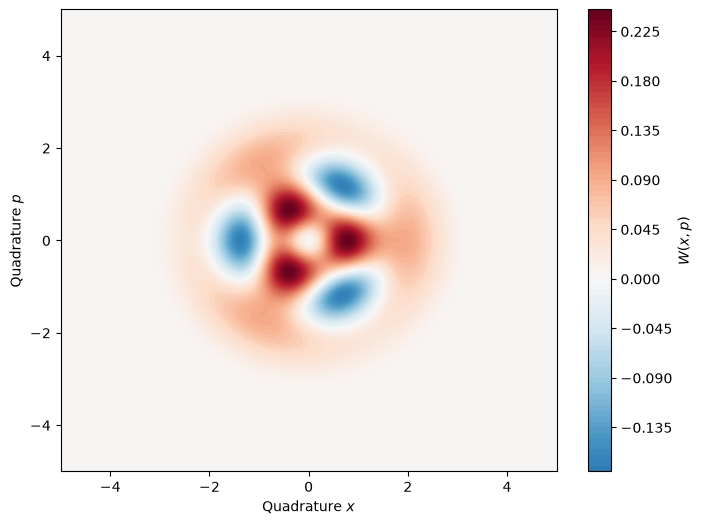

In [70]:
plot_Wigner(state)

In [71]:
# Define sampling parameters
N_angles = 8
N_samples_theta = 1000
x_range = (-5,5)
x_points = 400
x_array = np.linspace(x_range[0],x_range[1],x_points)
# Sample the selected state
thetas, samles = sample_homodyne(state=state,n_angles=N_angles,n_samples_theta=N_samples_theta,
                         bin_data=False,x_vec=x_array)

In [78]:
# Set MLE parameters
N_bins_array = np.arange(5, 20, 5)
iterations = 10

rho_init = np.zeros((N_cutoff, N_cutoff), dtype=complex)
rho_init[0,0] = 1.0

# Arrays to store results
rhos = []
fidelities = []

# Initialize MLE estimator
MLE_estimator = MLE(data=samles, N_bins=N_bins_array[0], N_cutoff=N_cutoff)

for N_bins in N_bins_array:
    MLE_estimator.set_binning(N_bins)

    rho_current = rho_init
    rhos_bin = [rho_current]
    fidelities_bin = []
    for i in tqdm(range(iterations)):
        rho_current = MLE_estimator.one_iteration(rho_current)
        
        fidelities_bin.append(q.fidelity(q.Qobj(rho_current), q.Qobj(state))**2)
        rhos_bin.append(rho_current)
    rhos.append(rhos_bin)
    fidelities.append(fidelities_bin)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

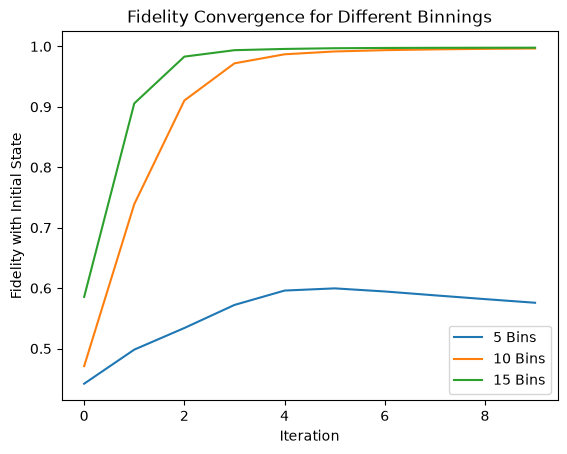

In [79]:
# Plot the fidelity convergence for each binning
for i, N_bins in enumerate(N_bins_array):
    plt.plot(fidelities[i][:], label=f'{N_bins} Bins')
plt.xlabel('Iteration')
plt.ylabel('Fidelity with Initial State')
plt.title('Fidelity Convergence for Different Binnings')
plt.legend()
plt.show()

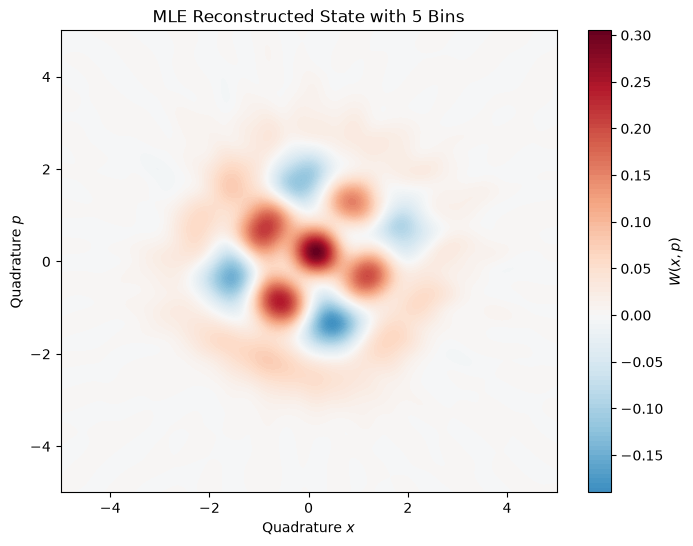

In [82]:
plot_Wigner(q.Qobj(rhos[0][-1]), xvec=x_array, title='MLE Reconstructed State with 5 Bins')

  0%|          | 0/100 [00:00<?, ?it/s]

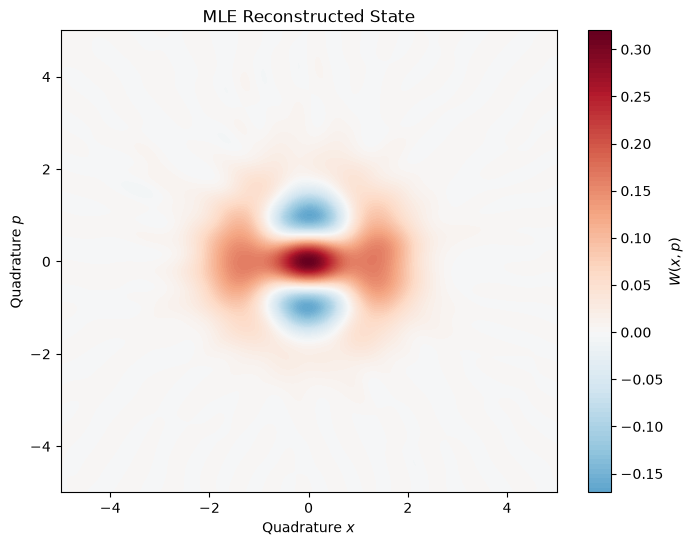

In [39]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

rho_current = initial_rho
rhos = [rho_current]
fidelities = []
for i in tqdm(range(100)):
    rho_current = MLE_estimator.one_iteration(rho_current)
    rhos.append(rho_current)
    fidelities.append(q.fidelity(q.Qobj(rhos[-1]), q.Qobj(rhos[-2]))**2)
plot_Wigner(q.Qobj(rhos[-1]), xvec=x_array, title='MLE Reconstructed State')